In [40]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

import scanpy as sc
import squidpy as sq
import anndata as ad
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import seaborn as sns

We will analyze data coming from one of the four donors reported in the paper. All the data will be loaded in the same spatialdata object and analyzed

In [14]:
DATA = '/Users/sergio/Spatiotemporal_roadmap_of_human_skin_wound_healing/data/GSE241124_RAW'
OUT = '/Users/sergio/Spatiotemporal_roadmap_of_human_skin_wound_healing/output/'
SAMPLES = ["Skin", "Wound1", "Wound7", "Wound30"]
METRICS = ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
TITLES = {
    "total_counts": "Total UMIs per spot",
    "n_genes_by_counts": "Detected genes per spot",
    "pct_counts_mt": "% mitochondrial counts per spot",
}

sns.set_style("whitegrid")

In [15]:
# create one SpatialData object per sample
sdatas = {
    s: spatialdata_io.visium(f"{DATA}/{s}", dataset_id=s)
    for s in SAMPLES
}

/opt/homebrew/Cellar/micromamba/2.9.0/envs/skinwound/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/homebrew/Cellar/micromamba/2.9.0/envs/skinwound/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/homebrew/Cellar/micromamba/2.9.0/envs/skinwound/lib/python3.11/site-packages/spatialdata/models/models.py:1235: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)
/opt/homebrew/Cellar/micromamba/2.9.0/envs/skinwound/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/homebrew/Cellar/micromamba/

In [16]:
# Inspect the SpatialData objects

# sdatas

In [17]:
def add_mt_flag(adata):
    adata.var["mt"] = adata.var_names.str.startswith("MT-")

In [18]:
def qc_metrics(adata):
    add_mt_flag(adata)
    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["mt"],
        percent_top=None,
        log1p=False,
        inplace=True,
    )
    return adata

In [19]:
adatas = {}
for s in SAMPLES:
    table = sdatas[s]["table"].copy()
    qc_metrics(table)
    table.obs["sample"] = s
    adatas[s] = table
    print(f"{s}: {table.n_obs} spots, {table.n_vars} genes")

Skin: 880 spots, 36600 genes
Wound1: 1745 spots, 36600 genes
Wound7: 1334 spots, 36600 genes
Wound30: 1996 spots, 36600 genes


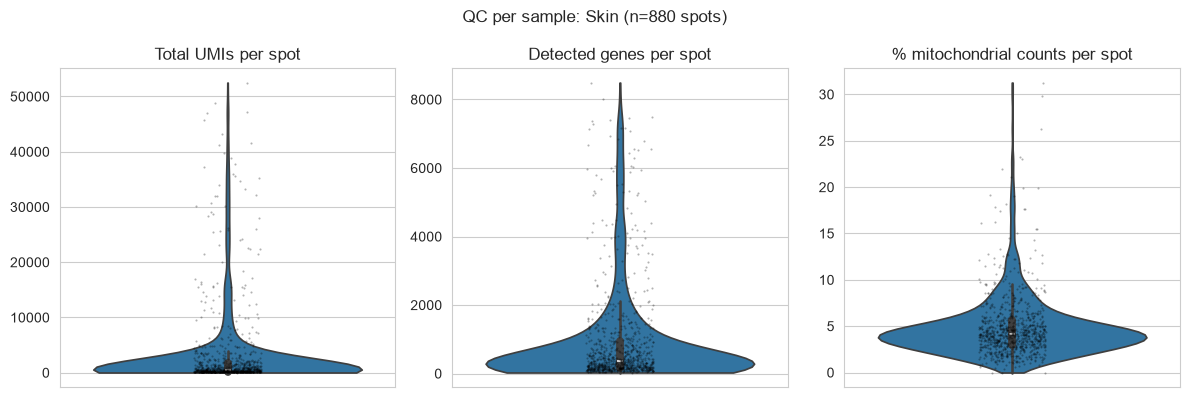

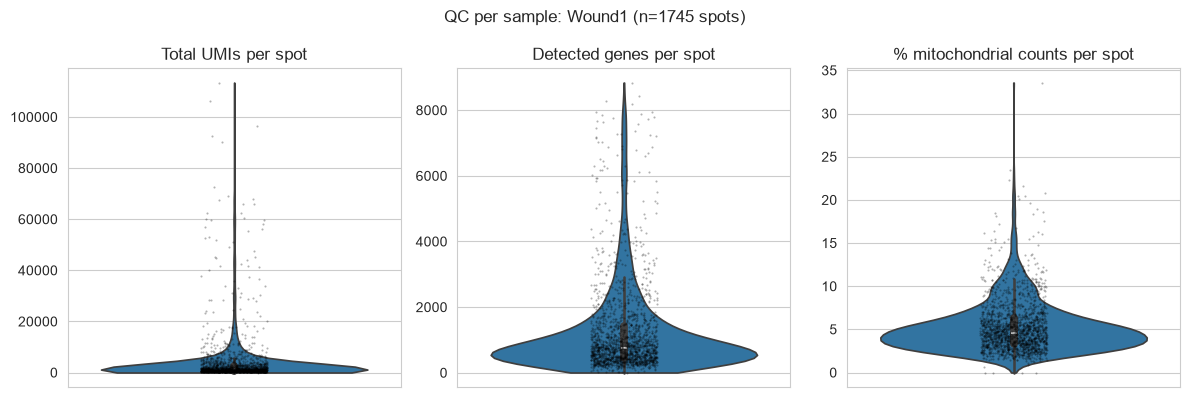

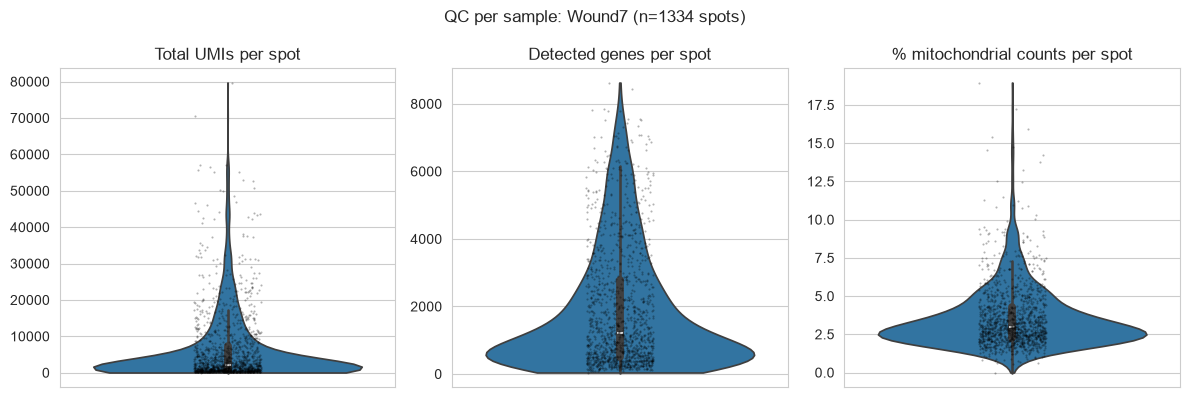

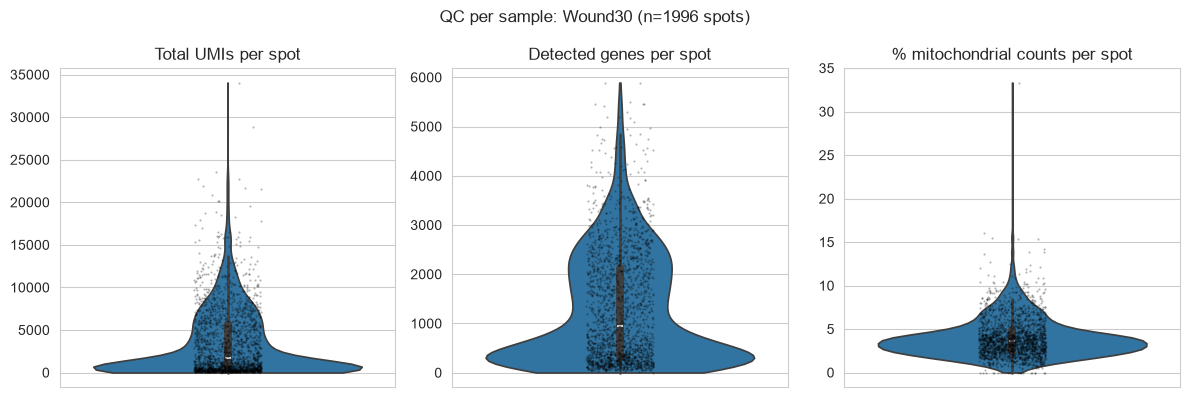

In [20]:
# 3) visualize QC metrics per sample
for s in SAMPLES:
    a = adatas[s]
    fig, axes = plt.subplots(1, len(METRICS), figsize=(12, 4))
    for ax, metric in zip(axes, METRICS):
        sns.violinplot(y=a.obs[metric], ax=ax, inner="box", cut=0)
        sns.stripplot(y=a.obs[metric], ax=ax, color="black", size=1.5, alpha=0.3)
        ax.set_title(TITLES[metric])
        ax.set_ylabel("")
    fig.suptitle(f"QC per sample: {s} (n={a.n_obs} spots)")
    fig.tight_layout()
    plt.show()

In [21]:
# Combined QC

## combine all samples into one object
sdata_all = sd.concatenate(list(sdatas.values()), concatenate_tables=True) # this does the merge of the sdatas. concatenate_tables=True means the underlying tables (the spot/cell matrix tables) are concatenated together, so all spots from all samples end up in one shared table
table_all = sdata_all["table"].copy() # This extracts the main table from the merged SpatialData object.
qc_metrics(table_all) # This runs the QC function on the merged table

/opt/homebrew/Cellar/micromamba/2.9.0/envs/skinwound/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/homebrew/Cellar/micromamba/2.9.0/envs/skinwound/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/homebrew/Cellar/micromamba/2.9.0/envs/skinwound/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 5955 × 36600
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [22]:
table_all.obs

,in_tissue,array_row,array_col,spot_id,region,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
AAACCGTTCGTCCAGG-1,1,52,42,0,Skin,352,540.0,40.0,7.407407
AAACGAGACGGTTGAT-1,1,35,79,1,Skin,390,548.0,33.0,6.021898
AAACTGCTGGCTCCAA-1,1,45,67,2,Skin,698,1404.0,128.0,9.116809
AAATAACCATACGGGA-1,1,14,88,3,Skin,106,128.0,6.0,4.687500
AAATACCTATAAGCAT-1,1,47,69,4,Skin,733,1304.0,80.0,6.134969
...,...,...,...,...,...,...,...,...,...
TTGTGTTTCCCGAAAG-1-3,1,51,59,1991,Wound30,1200,2329.0,55.0,2.361529
TTGTTAGCAAATTCGA-1-1,1,22,42,1992,Wound30,2177,5980.0,198.0,3.311037
TTGTTCAGTGTGCTAC-1-3,1,24,64,1993,Wound30,2046,4754.0,124.0,2.608330
TTGTTGTGTGTCAAGA-1-3,1,31,77,1994,Wound30,352,459.0,14.0,3.050109


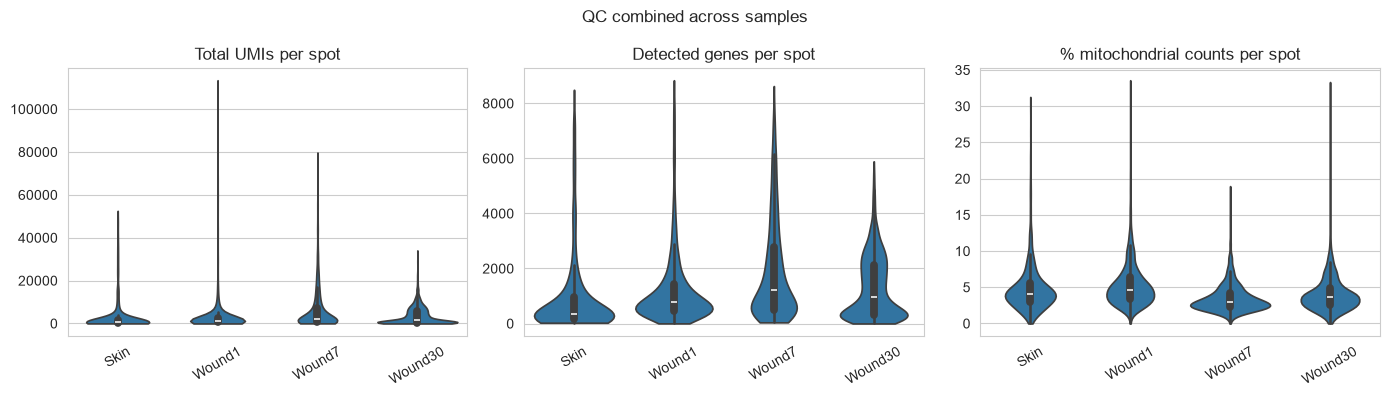

In [24]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(14, 4))
for ax, metric in zip(axes, METRICS):
    sns.violinplot(
        data=table_all.obs,
        x="region",
        y=metric,
        order=SAMPLES,
        ax=ax,
        inner="box",
        cut=0
    )
    ax.set_title(TITLES[metric])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("QC combined across samples")
fig.tight_layout()
plt.show()

Visualize the metrics on the tissue, by using the squidpy command sq.pl.spatial_scatter()
If we worked with anndata structures, something like this would work:

```python
for s in SAMPLES:
    adata = adatas[s]
    sq.pl.spatial_scatter(adata color="log1p_n_genes_by_counts")
    sq.pl.spatial_scatter(adata)
```

But spatialdata_io.visium() does not save images in the classical structure adata.uns["spatial"][library_id]["images"] that sq.pl.spatial_scatter() expects. In a spatialdata structure, images are separated elements, e.g., sdata.images["Skin_hires_image"], and not inside a .uns slot. 

Then, in order to use sq.pl.spatial_scatter(), we need to reconstruct the demanded structure.
It will be done through a custom function in the cell below.

Note: you are not obliged to do that, this is not a fundamental part of the analysis, it is just a further visual inspection of our data.


In [27]:
import json

def attach_spatial_uns(adata, sdata, sample, data_folder):
    hires = sdata.images[f"{sample}_hires_image"].transpose("y", "x", "c").to_numpy()
    lowres = sdata.images[f"{sample}_lowres_image"].transpose("y", "x", "c").to_numpy()
    with open(f"{data_folder}/{sample}/spatial/scalefactors_json.json") as f:
        scalefactors = json.load(f)
    adata.uns["spatial"] = {
        sample: {
            "images": {"hires": hires, "lowres": lowres},
            "scalefactors": scalefactors,
            "metadata": {},
        }
    }

In [36]:
# # Now we can run:
# for s in SAMPLES:
#     adata = adatas[s]
#     attach_spatial_uns(adata, sdatas[s], s, DATA)
#     sq.pl.spatial_scatter(adata)
#     sq.pl.spatial_scatter(adata, color="n_genes_by_counts")

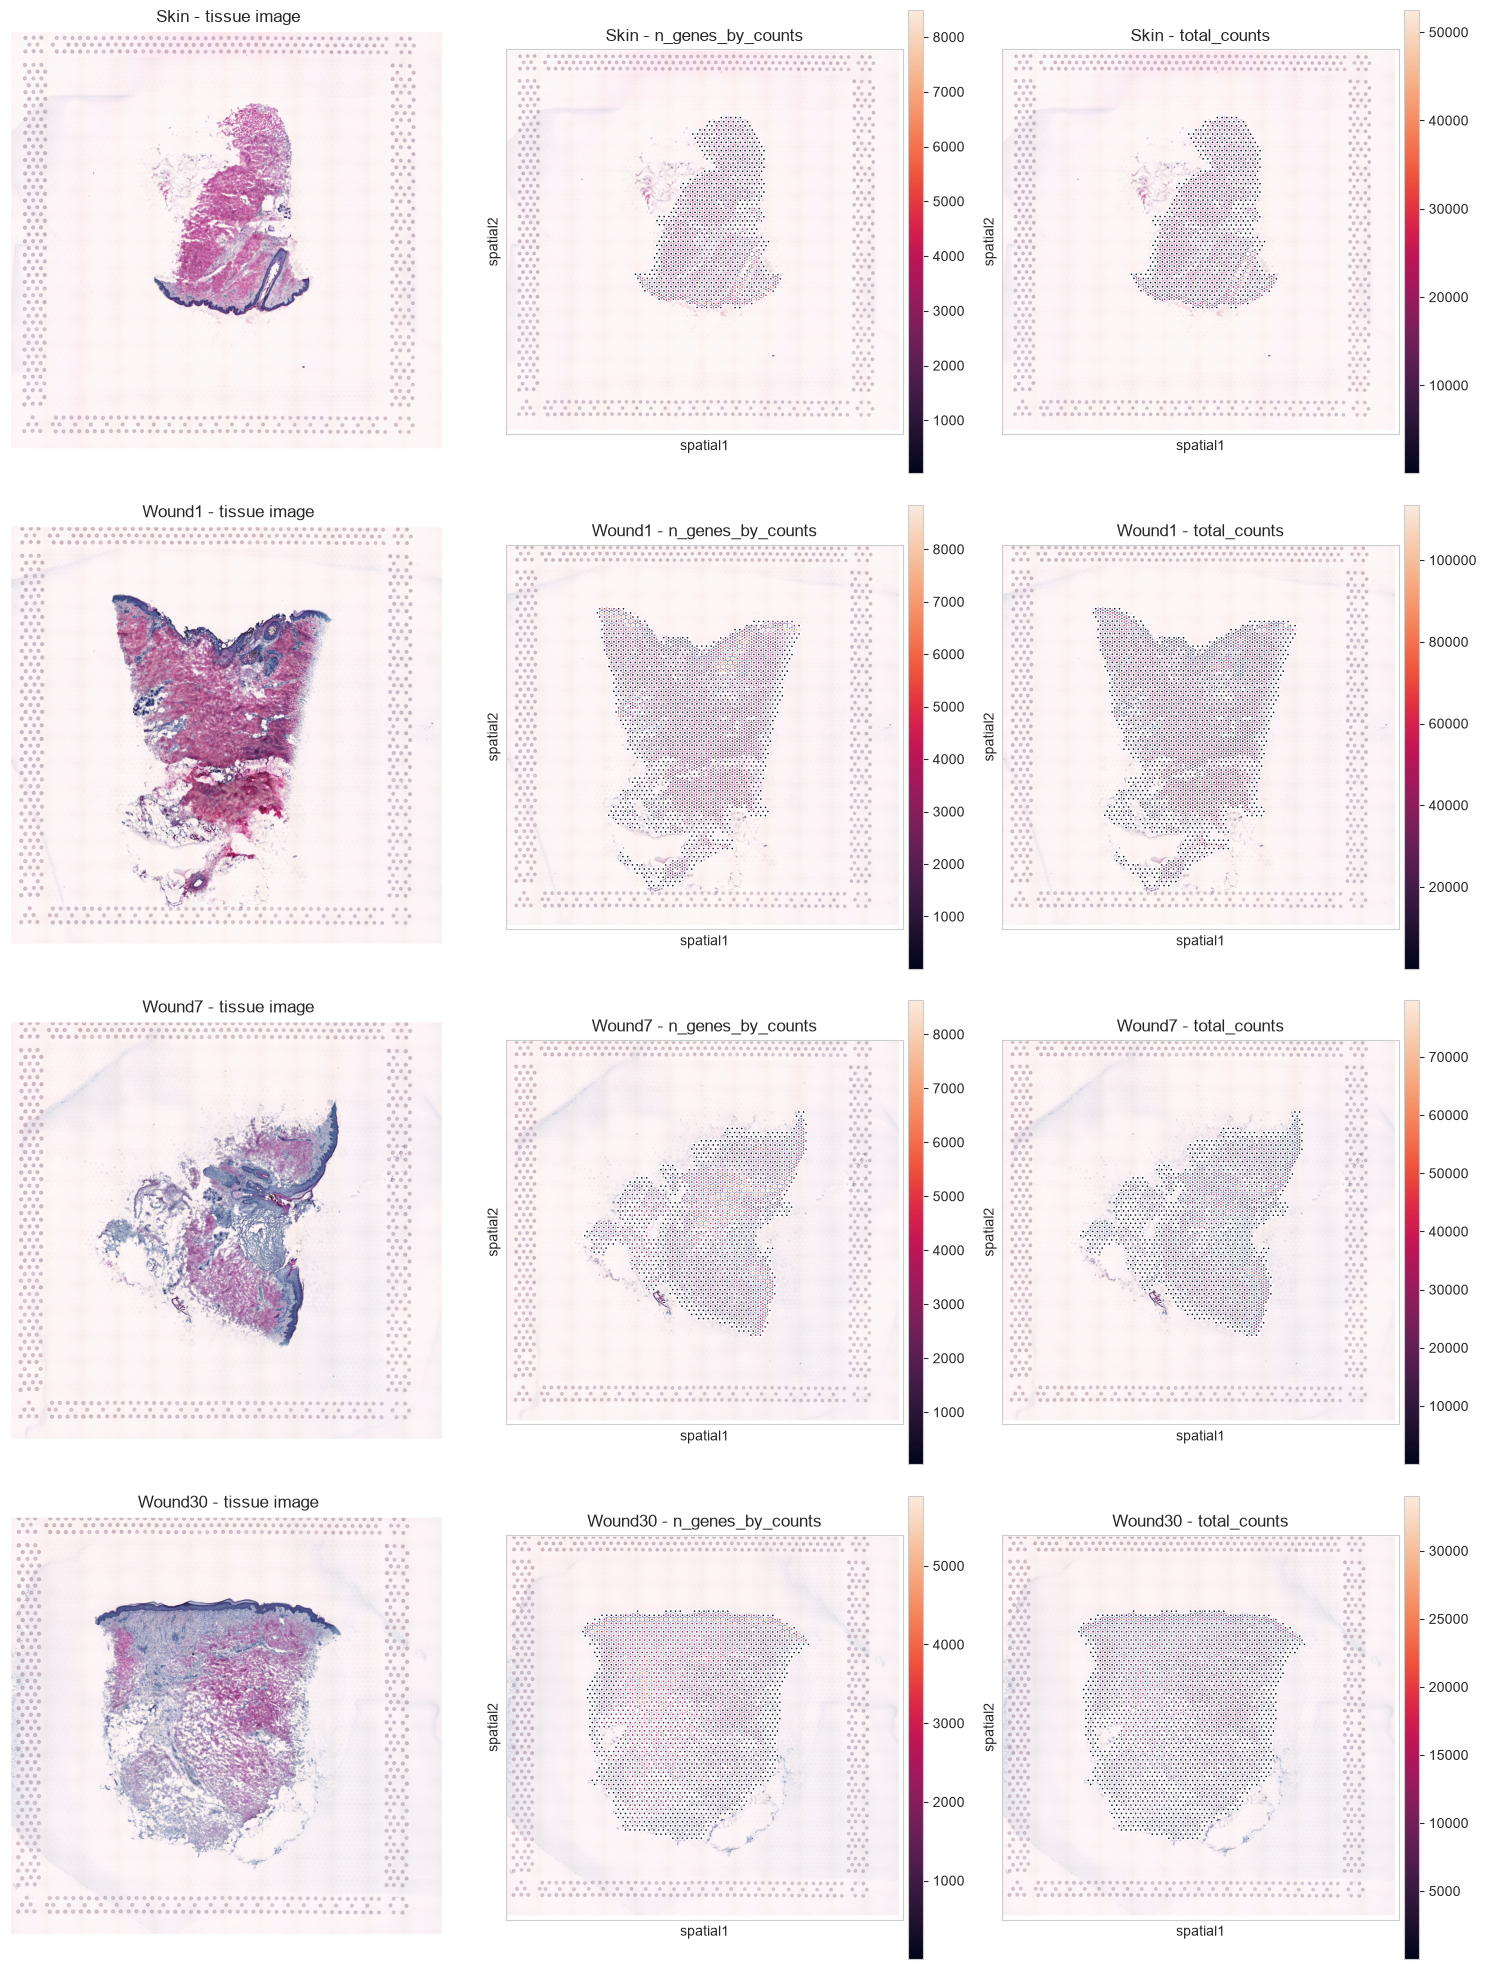

In [35]:
fig, axes = plt.subplots(len(SAMPLES), 3, figsize=(15, 5 * len(SAMPLES)))

for row, s in enumerate(SAMPLES):
    adata = adatas[s]
    img = adata.uns["spatial"][s]["images"]["hires"]

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{s} - tissue image")
    axes[row, 0].axis("off")

    sq.pl.spatial_scatter(adata, color="n_genes_by_counts", ax=axes[row, 1], title=f"{s} - n_genes_by_counts")
    sq.pl.spatial_scatter(adata, color="total_counts", ax=axes[row, 2], title=f"{s} - total_counts")

fig.tight_layout()

Filtering per-sample

In [38]:
# Thresholds chosen by inspecting the per-sample violin plots produced above.
# Adjust these values if you disagree with where the low-quality tail starts
# for a given sample.
MIN_GENES_PER_SAMPLE = {
    "Skin": 75,
    "Wound1": 200,
    "Wound7": 200,
    "Wound30": 100,
}


In [39]:
for s in SAMPLES:
    n_before = adatas[s].n_obs
    sc.pp.filter_cells(adatas[s], min_genes=MIN_GENES_PER_SAMPLE[s])
    n_after = adatas[s].n_obs
    print(
        f"{s}: min_genes={MIN_GENES_PER_SAMPLE[s]} -> "
        f"{n_before} to {n_after} spots ({n_before - n_after} removed, "
        f"{(n_before - n_after) / n_before * 100:.1f}%)"
    )

Skin: min_genes=75 -> 880 to 841 spots (39 removed, 4.4%)
Wound1: min_genes=200 -> 1745 to 1692 spots (53 removed, 3.0%)
Wound7: min_genes=200 -> 1334 to 1278 spots (56 removed, 4.2%)
Wound30: min_genes=100 -> 1996 to 1922 spots (74 removed, 3.7%)


Collective filter on genes 

In [41]:
table_all = ad.concat(
    [adatas[s] for s in SAMPLES],
    join="inner", # This parameter decides what to do with the variables (genes) that are not shared across all samples. "inner" means only keep genes that are present in all samples.
    index_unique="-", # This parameter decides how to handle duplicate indices
    keys=SAMPLES #this parameter assigns a key to each concatenated object
)

In [42]:
n_genes_before = table_all.n_vars
sc.pp.filter_genes(table_all, min_cells=3)
print(
    f"Genes: {n_genes_before} -> {table_all.n_vars} "
    f"({n_genes_before - table_all.n_vars} removed)"
)
print(f"Combined table: {table_all.shape[0]} spots x {table_all.shape[1]} genes")
print(table_all.obs["sample"].value_counts())

Genes: 36600 -> 20311 (16289 removed)
Combined table: 5733 spots x 20311 genes
sample
Wound30    1922
Wound1     1692
Wound7     1278
Skin        841
Name: count, dtype: int64


### Filtering out cells with high percentage of mitocondrial genes.
##### Do we really need to do that?

In [ ]:
# # demo only - NOT applied to the data
# n_would_remove = (table_all.obs["pct_counts_mt"] > 20).sum()
# print(
#     f"Spots with pct_counts_mt > 20%: {n_would_remove} / {table_all.n_obs} "
#     f"({n_would_remove / table_all.n_obs * 100:.2f}%)"
# )



In this dataset that threshold would remove almost nothing. In **intact tissue** (as opposed to a dissociated single-cell suspension), a spot's mitochondrial fraction does not primarily reflect membrane damage: it can just as well reflect a metabolically very active tissue region (e.g. proliferative/inflammatory zones during wound healing).
Filtering spots on `pct_counts_mt` therefore risks discarding real biological signal rather than technical noise — and, as we just saw, it removes very few spots anyway, so it would not have meaningfully improved data quality here.

This is exactly the reasoning behind the QC strategy used in the original publication for their ST-seq data. Rather than filtering spots on mitochondrial content, they removed three families of highly and uniformly
expressed, but largely uninformative, genes **from the expression matrix itself**, collectively across all sections:

- **`MALAT1`** — an extremely abundant, ubiquitously expressed nuclear lncRNA.
  Because its expression barely varies between cell types, it contributes
  little discriminative signal, but its very high, variable capture
  efficiency (driven by nuclear retention and technical factors rather than
  biology) can dominate normalization and distort clustering/PCA if left in.
- **Mitochondrial genes** — rather than using `pct_counts_mt` as a
  spot-exclusion criterion (which, as shown above, is not a reliable quality
  signal in intact tissue), the mitochondrial genes themselves are removed
  from the matrix. Their expression reflects metabolic state / technical
  capture bias more than cell identity, and can otherwise add nuisance
  variation to HVG selection and PCA.
- **Hemoglobin genes** (`HBA1`, `HBA2`, `HBB`, `HBD`, `HBE1`, `HBG1`, `HBG2`,
  `HBM`, `HBQ1`, `HBZ`) — markers of red blood cell contamination. Wound
  tissue is prone to local bleeding, so some spots capture a mix of real
  tissue and red blood cells (or their ambient RNA). Left in, these genes can
  dominate the profile of an otherwise normal spot and create spurious
  "erythrocyte-like" clusters.

We apply this filter collectively (not per sample).

In [43]:
HEMOGLOBIN_GENES = [
    "HBA1", "HBA2", "HBB", "HBD", "HBE1",
    "HBG1", "HBG2", "HBM", "HBQ1", "HBZ",
]

mt_genes = table_all.var_names[table_all.var_names.str.startswith("MT-")].tolist()
hb_genes = [g for g in HEMOGLOBIN_GENES if g in table_all.var_names]
malat1_gene = [g for g in ["MALAT1"] if g in table_all.var_names]

# NOTE: don't match hemoglobin genes with a "starts with HB" regex/prefix -
# it would also catch HBEGF (a real, biologically important wound-healing
# growth factor), HBP1 and HBS1L, none of which are hemoglobin genes.
# Use the explicit official gene symbol list instead.

genes_to_remove = set(malat1_gene) | set(mt_genes) | set(hb_genes)
print(f"MALAT1: {malat1_gene}")
print(f"Mitochondrial genes ({len(mt_genes)}): {mt_genes}")
print(f"Hemoglobin genes ({len(hb_genes)}): {hb_genes}")
print(f"Total genes removed: {len(genes_to_remove)}")

n_genes_before = table_all.n_vars
table_all = table_all[:, ~table_all.var_names.isin(genes_to_remove)].copy()
print(f"Genes: {n_genes_before} -> {table_all.n_vars}")
print(f"Final table_all: {table_all.shape[0]} spots x {table_all.shape[1]} genes")

MALAT1: ['MALAT1']
Mitochondrial genes (13): ['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB']
Hemoglobin genes (9): ['HBA1', 'HBA2', 'HBB', 'HBD', 'HBG1', 'HBG2', 'HBM', 'HBQ1', 'HBZ']
Total genes removed: 23
Genes: 20311 -> 20288
Final table_all: 5733 spots x 20288 genes


Put back all the info in the spatialdata object and save it

In [46]:
sdata_all.tables["table"] = table_all   # sostituisce la tabella originale con quella filtrata/pulita
sdata_all.write("/Users/sergio/Spatiotemporal_roadmap_of_human_skin_wound_healing/data/processed_data/spatial_data_filtered.zarr", overwrite=True)

/opt/homebrew/Cellar/micromamba/2.9.0/envs/skinwound/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/opt/homebrew/Cellar/micromamba/2.9.0/envs/skinwound/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/opt/homebrew/Cellar/micromamba/2.9.0/envs/skinwound/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/opt/homebrew/Cellar/micromamba/2.9.0/envs/skinwound/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/opt/homebrew/Cellar/micromamba/2.9.0/envs/skinwound/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/opt/homebrew/Cellar/micromamba/2.9.0/en

In [47]:
# Load the sdata_all object 
# sdata_all = sd.read_zarr("path/to/checkpoint.zarr")